In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [ ]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['MatchID'], inplace= True)

    return df

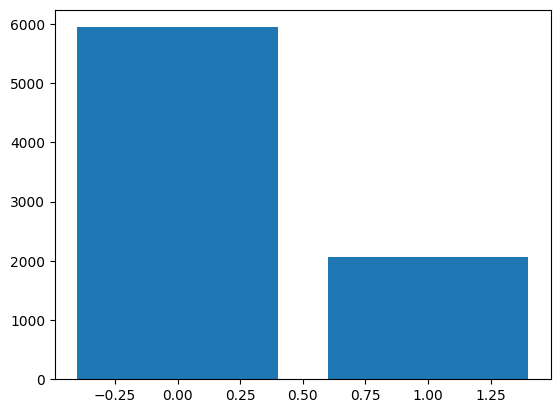

In [184]:
from sklearn.model_selection import train_test_split

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X= preprocess_data(train_df.drop(columns=['chaos_label']))
y= train_df['chaos_label']

X_train, X_eval, y_train, y_eval = train_test_split(X, y, train_size=0.8, stratify= y, random_state= seed)

X_test= preprocess_data(test_df)

plt.bar(np.unique_counts(y).values, np.unique_counts(y).counts)
plt.show()

In [185]:
# Subtask 1

answer1= pd.DataFrame({
    'subtaskID': 1,
    'datapointID': 1,
    'answer': [len(test_df[
        (test_df['HomeTeam'] == 'Chelsea') |
        (test_df['AwayTeam'] == 'Chelsea')
    ])]
})

answer1.head()

,subtaskID,datapointID,answer
0,1,1,150


In [ ]:
# Subtask 2

answer2= pd.DataFrame({
    'subtaskID': 2,
    'datapointID': test_df['MatchID'],
    'answer': test_df['TeamStyles'].apply(
        lambda x: sum([
            'AggressiveTackler' in x, 
            'RiskTaker' in x, 
            'HighPressure' in x, 
            'ChaosInducer' in x])
            / len(x.split())
            )
})

answer2.head()

,subtaskID,datapointID,answer
0,2,2021-2022_Man City_Arsenal,0.500000
1,2,2021-2022_Aston Villa_Brentford,1.000000
2,2,2021-2022_Brighton_Everton,0.666667
3,2,2021-2022_Newcastle_Southampton,0.000000
4,2,2021-2022_Norwich_Leicester,0.500000


In [ ]:
# Subtask 3

from catboost import CatBoostClassifier

cat_cols= X.drop(columns=['TeamStyles']).select_dtypes(include=['object', 'str']).columns.to_list()
text_cols= ['TeamStyles']

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    auto_class_weights= 'Balanced',
    cat_features= cat_cols,
    text_features= text_cols,
    early_stopping_rounds=200,
    random_state= seed,
    eval_metric="F1"
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose=200
)

0:	learn: 0.9230648	test: 0.9117146	best: 0.9117146 (0)	total: 5.4ms	remaining: 2.69s
100:	learn: 0.9379600	test: 0.9236585	best: 0.9245765 (96)	total: 373ms	remaining: 1.49s
200:	learn: 0.9431126	test: 0.9242959	best: 0.9282166 (174)	total: 707ms	remaining: 1.06s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9282166353
bestIteration = 174

Shrink model to first 175 iterations.


CatBoostClassifier(auto_class_weights='Balanced', cat_features=['Season', 'HomeTeam', 'AwayTeam', 'FullTimeResult'], depth=4, early_stopping_rounds=100, eval_metric='F1', iterations=500, learning_rate=0.05, random_state=42)

In [ ]:
predictions= model.predict(X_test)

answer3= pd.DataFrame({
    'subtaskID': 3,
    'datapointID': test_df['MatchID'],
    'answer': predictions
})

answer3.head()

,subtaskID,datapointID,answer
0,3,2021-2022_Man City_Arsenal,1
1,3,2021-2022_Aston Villa_Brentford,1
2,3,2021-2022_Brighton_Everton,0
3,3,2021-2022_Newcastle_Southampton,1
4,3,2021-2022_Norwich_Leicester,0


In [189]:
answer= pd.concat([answer1, answer2, answer3])

answer.to_csv("submission.csv", index= False)